PCA

原始数据尺寸：(7352, 562)
运动类别：['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']
固定降至2维
降至2维,累计方差解释率：0.5726
2维降维后数据尺寸:(7352, 2)


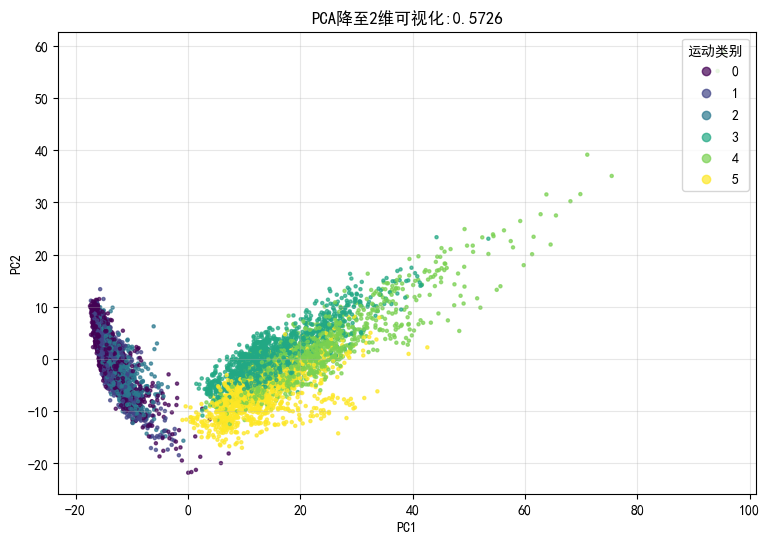

原始数据尺寸：(7352, 562)
运动类别原始名称列表：['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']
数字标签与真实运动名称对应表
数字 0 → 原始运动类别：LAYING
数字 1 → 原始运动类别：SITTING
数字 2 → 原始运动类别：STANDING
数字 3 → 原始运动类别：WALKING
数字 4 → 原始运动类别：WALKING_DOWNSTAIRS
数字 5 → 原始运动类别：WALKING_UPSTAIRS
 实验2:保留90%信息
满足90%信息保留所需主成分维度：64
实际累计方差解释率：0.9013
建模用降维数据尺寸：(7352, 64)
前10个主成分各自方差占比
第1主成分：0.5069
第2主成分：0.0657
第3主成分：0.0280
第4主成分：0.0250
第5主成分：0.0188
第6主成分：0.0172
第7主成分：0.0137
第8主成分：0.0120
第9主成分：0.0100
第10主成分：0.0096


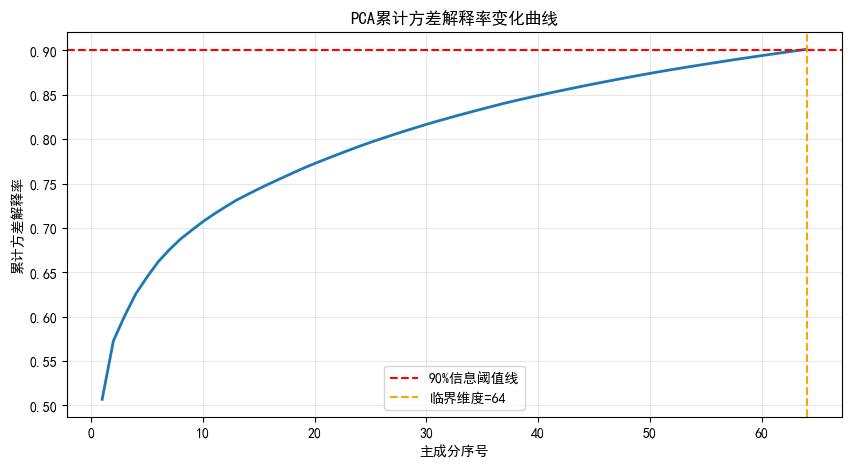

C:\Users\Administrator\AppData\Local\Temp\ipykernel_12824\3544925941.py:89: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  T2_90[i] = zi @ inv_lambda_90 @ zi.T
C:\Users\Administrator\AppData\Local\Temp\ipykernel_12824\3544925941.py:105: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  T2_2[i] = zi @ inv_lambda_2 @ zi.T


PCA定量指标对比
2维PCA 平均T²:1.9997
2维PCA 平均SPE:240.1891
64维90%阈值PCA 平均T²:63.9913
64维90%阈值PCA 平均SPE:55.4534


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
plt.rcParams["font.family"]=["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"]=False

#读取数据
df=pd.read_csv("C:/Users/Administrator/Desktop/机器学习/train.csv")
X=df.select_dtypes(include=[np.number]).values
y_text=df.iloc[:, -1].values  

le=LabelEncoder()
y=le.fit_transform(y_text)
print(f"原始数据尺寸：{X.shape}")
print(f"运动类别：{le.classes_}")

#标准化预处理
scaler=StandardScaler()
X_std=scaler.fit_transform(X)

#实验1：固定降至2维
print("固定降至2维")
pca_2d=PCA(n_components=2)
X_pca_2=pca_2d.fit_transform(X_std)
ratio_2=sum(pca_2d.explained_variance_ratio_)
print(f"降至2维,累计方差解释率：{ratio_2:.4f}")
print(f"2维降维后数据尺寸:{X_pca_2.shape}")

#绘制2维散点图
plt.figure(figsize=(9, 6))
sc=plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, s=5, alpha=0.7)
plt.title(f"PCA降至2维可视化:{ratio_2:.4f}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.legend(*sc.legend_elements(), title="运动类别", loc="upper right")
plt.show()

le=LabelEncoder()
y=le.fit_transform(y_text)
print(f"原始数据尺寸：{X.shape}")
print(f"运动类别原始名称列表：{le.classes_}")

print("数字标签与真实运动名称对应表")
for num_label, real_name in enumerate(le.classes_):
    print(f"数字 {num_label} → 原始运动类别：{real_name}")

    
#实验2：保留90%信息
print(" 实验2:保留90%信息")
pca_model=PCA(n_components=0.90)
X_pca_model=pca_model.fit_transform(X_std)

dim_90=pca_model.n_components_
total_ratio=sum(pca_model.explained_variance_ratio_)
print(f"满足90%信息保留所需主成分维度：{dim_90}")
print(f"实际累计方差解释率：{total_ratio:.4f}")
print(f"建模用降维数据尺寸：{X_pca_model.shape}")

#输出前10个主成分单独方差占比
print("前10个主成分各自方差占比")
for idx, r in enumerate(pca_model.explained_variance_ratio_[:10]):
    print(f"第{idx+1}主成分：{r:.4f}")

# 绘制累计方差曲线
cum_ratio=np.cumsum(pca_model.explained_variance_ratio_)
plt.figure(figsize=(10,5))
plt.plot(range(1, len(cum_ratio)+1), cum_ratio, linewidth=2)
plt.axhline(y=0.90, color="r", linestyle="--", label="90%信息阈值线")
plt.axvline(x=dim_90, color="orange", linestyle="--", label=f"临界维度={dim_90}")
plt.title("PCA累计方差解释率变化曲线")
plt.xlabel("主成分序号")
plt.ylabel("累计方差解释率")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#计算90%维度PCA的T²、SPE量化指标 
n_sample=X_std.shape[0]
eig_vals_90=pca_model.explained_variance_
inv_lambda_90=np.diag(1/eig_vals_90)

#计算T²统计量
T2_90=np.zeros(n_sample)
for i in range(n_sample):
    zi=X_pca_model[i:i+1, :]
    T2_90[i]=zi@inv_lambda_90@zi.T
avg_T2_90=np.mean(T2_90)

#计算SPE
X_recon_90=X_pca_model@pca_model.components_
residual_90=X_std-X_recon_90
SPE_90=np.sum(residual_90**2,axis=1)
avg_SPE_90=np.mean(SPE_90)

#计算2维PCA的T²、SPE
n_sample=X_std.shape[0]
eig_vals_2=pca_2d.explained_variance_
inv_lambda_2=np.diag(1/eig_vals_2)
T2_2=np.zeros(n_sample)
for i in range(n_sample):
    zi=X_pca_2[i:i+1,:]
    T2_2[i]=zi@inv_lambda_2@zi.T
avg_T2_2=np.mean(T2_2)

X_recon_2=X_pca_2@pca_2d.components_
residual_2=X_std-X_recon_2
SPE_2=np.sum(residual_2**2,axis=1)
avg_SPE_2=np.mean(SPE_2)

print("PCA定量指标对比")
print(f"2维PCA 平均T²:{avg_T2_2:.4f}")
print(f"2维PCA 平均SPE:{avg_SPE_2:.4f}")
print(f"{dim_90}维90%阈值PCA 平均T²:{avg_T2_90:.4f}")
print(f"{dim_90}维90%阈值PCA 平均SPE:{avg_SPE_90:.4f}")

KPCA

原始样本数量 m=7352, 原始特征维度 d=562
6类运动标签映:
数字0 → LAYING
数字1 → SITTING
数字2 → STANDING
数字3 → WALKING
数字4 → WALKING_DOWNSTAIRS
数字5 → WALKING_UPSTAIRS
KPCA 2维可视化实验(RBF高斯核 gamma=0.001) 
2维KPCA降维后数据尺寸 (7352, 2)
2维KPCA 各维度方差贡献率:PC1=0.8267, PC2=0.1733
2维KPCA 累计方差贡献率：1.0000
2维KPCA 核空间平均T²_K:0.0003
2维KPCA 预像近似原始空间平均SPE:309.1852


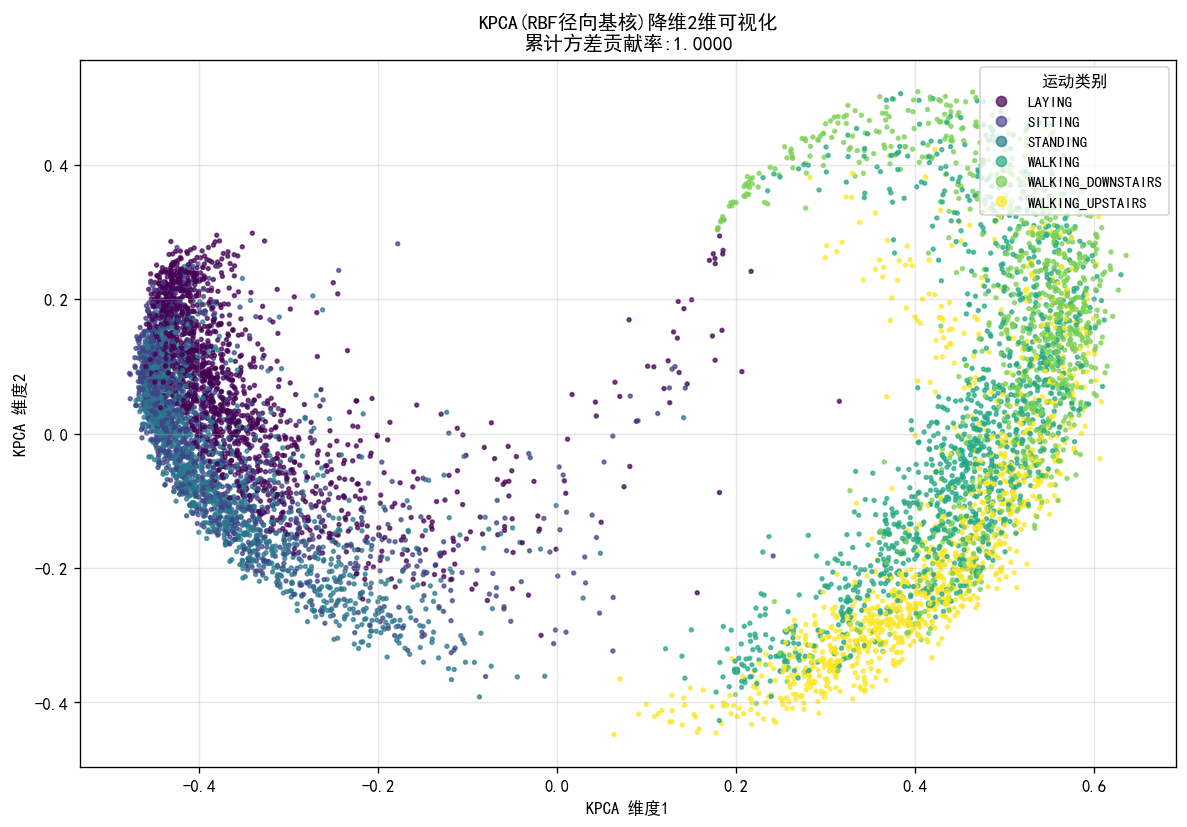

KPCA 40维高维嵌入
40维KPCA降维后尺寸:(7352, 40)
40维KPCA前10维方差贡献率:
第1维贡献率：0.4673
第2维贡献率：0.0979
第3维贡献率：0.0581
第4维贡献率：0.0438
第5维贡献率：0.0294
第6维贡献率：0.0260
第7维贡献率：0.0222
第8维贡献率：0.0177
第9维贡献率：0.0162
第10维贡献率：0.0132
40维KPCA整体累计方差贡献率:1.0000
40维KPCA 核空间平均T²_K:0.0054
40维KPCA 预像近似原始空间平均SPE:281.5833


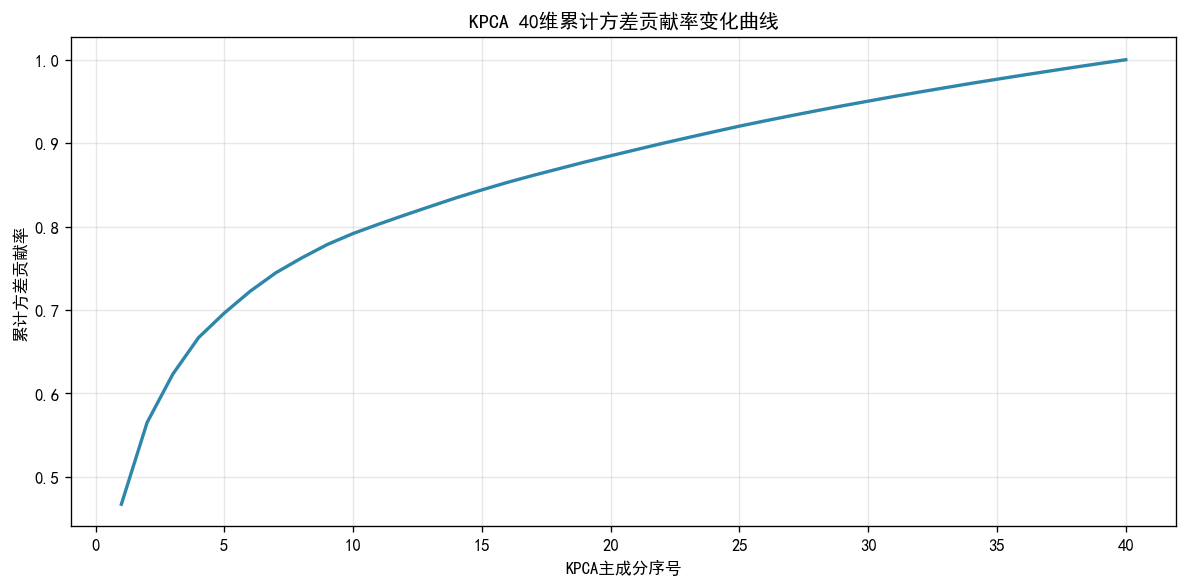

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
plt.rcParams["font.family"]=["SimHei","Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"]=False
plt.rcParams["figure.dpi"]=120
FILE_PATH=r"C:/Users/Administrator/Desktop/机器学习/train.csv"

def calc_kpca_metrics(X_kpca,kpca_model, X_std):
    "向量化批量计算T²_K、近似SPE、方差贡献率相关指标"
    eig=kpca_model.eigenvalues_
    inv_eig_mat=np.diag(1/eig)
    T2_arr=np.sum((X_kpca@inv_eig_mat)*X_kpca,axis=1)
    avg_T2=np.mean(T2_arr)
    #预像重构近似原始特征，计算SPE
    X_recon=kpca_model.inverse_transform(X_kpca)
    SPE_arr=np.sum((X_std-X_recon)**2,axis=1)
    avg_SPE=np.mean(SPE_arr)
    #计算各主成分方差贡献率、累计方差贡献率
    total_eig_sum=np.sum(eig)
    var_ratio=eig/total_eig_sum
    cum_var_ratio=np.cumsum(var_ratio)
    return avg_T2,avg_SPE,var_ratio,cum_var_ratio

if __name__=="__main__":
    try:
        df=pd.read_csv(FILE_PATH)
    except FileNotFoundError:
        print("文件路径错误,请检查csv路径!")
        exit()
    X=df.select_dtypes(include=[np.number]).values
    y_text=df.iloc[:, -1].values
    le=LabelEncoder()
    y=le.fit_transform(y_text)
    m, d=X.shape
    print(f"原始样本数量 m={m}, 原始特征维度 d={d}")
    print(f"6类运动标签映:")
    for num,name in enumerate(le.classes_):
        print(f"数字{num} → {name}")

    #Z-score标准化
    scaler=StandardScaler()
    X_std=scaler.fit_transform(X)

    #实验1：2维KPCA可视化（RBF径向基核）
    print("KPCA 2维可视化实验(RBF高斯核 gamma=0.001) ")
    kpca_2=KernelPCA(
        n_components=2,
        kernel="rbf",
        gamma=0.001,
        fit_inverse_transform=True,
        random_state=42
    )
    X_kpca_2=kpca_2.fit_transform(X_std)
    print(f"2维KPCA降维后数据尺寸 {X_kpca_2.shape}")
    #计算指标：平均T2、平均SPE、方差贡献率、累计贡献率
    avg_T2_kpca_2,avg_SPE_pre_2,var_ratio_2,cum_var_2=calc_kpca_metrics(X_kpca_2,kpca_2,X_std)
    print(f"2维KPCA 各维度方差贡献率:PC1={var_ratio_2[0]:.4f}, PC2={var_ratio_2[1]:.4f}")
    print(f"2维KPCA 累计方差贡献率：{cum_var_2[-1]:.4f}")
    print(f"2维KPCA 核空间平均T²_K:{avg_T2_kpca_2:.4f}")
    print(f"2维KPCA 预像近似原始空间平均SPE:{avg_SPE_pre_2:.4f}")

    #绘制二维散点图
    plt.figure(figsize=(10,7))
    sc=plt.scatter(X_kpca_2[:, 0],X_kpca_2[:, 1],c=y,s=5,alpha=0.7)
    plt.title(f"KPCA(RBF径向基核)降维2维可视化\n累计方差贡献率:{cum_var_2[-1]:.4f}")
    plt.xlabel("KPCA 维度1")
    plt.ylabel("KPCA 维度2")
    plt.grid(alpha=0.3)
    handles,_=sc.legend_elements()
    plt.legend(handles,le.classes_,title="运动类别",loc="upper right",fontsize=9)
    plt.tight_layout()
    plt.savefig("kpca_2d_rbf.png")
    plt.show()

    #实验2：40维KPCA 
    print("KPCA 40维高维嵌入")
    kpca_40=KernelPCA(
        n_components=40,
        kernel="rbf",
        gamma=0.001,
        fit_inverse_transform=True,
        random_state=42
    )
    X_kpca_40=kpca_40.fit_transform(X_std)
    print(f"40维KPCA降维后尺寸:{X_kpca_40.shape}")
    avg_T2_kpca_40,avg_SPE_pre_40,var_ratio_40,cum_var_40=calc_kpca_metrics(X_kpca_40,kpca_40,X_std)
    print(f"40维KPCA前10维方差贡献率:")
    for idx,r in enumerate(var_ratio_40[:10]):
        print(f"第{idx+1}维贡献率：{r:.4f}")
    print(f"40维KPCA整体累计方差贡献率:{cum_var_40[-1]:.4f}")
    print(f"40维KPCA 核空间平均T²_K:{avg_T2_kpca_40:.4f}")
    print(f"40维KPCA 预像近似原始空间平均SPE:{avg_SPE_pre_40:.4f}")

    #绘制40维累计方差贡献率曲线
    plt.figure(figsize=(10,5))
    plt.plot(range(1, len(cum_var_40)+1), cum_var_40, linewidth=2, color="#2E86AB")
    plt.title("KPCA 40维累计方差贡献率变化曲线")
    plt.xlabel("KPCA主成分序号")
    plt.ylabel("累计方差贡献率")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("kpca_40_cum_variance.png")
    plt.show()

    print()

